In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator

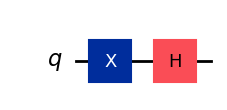

In [3]:
qc = QuantumCircuit(1)
qc.x(0)
qc.h(0)
qc.draw('mpl')

In [6]:
q = Statevector(qc)
q.draw('latex')

<IPython.core.display.Latex object>

In [8]:
q.probabilities()

array([0.5, 0.5])

In [21]:
q.sample_counts(100)

{np.str_('0'): np.int64(46), np.str_('1'): np.int64(54)}

In [35]:
U = Operator(qc)
U.draw('latex')

QiskitError: 'Cannot apply operation with classical bits: measure'

In [30]:
X = Operator.from_label('X')
H = Operator.from_label('H')

In [ ]:
U = H @ X
U.draw('latex')

<IPython.core.display.Latex object>

In [42]:
from qiskit.providers.basic_provider import BasicSimulator
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import SamplerV2

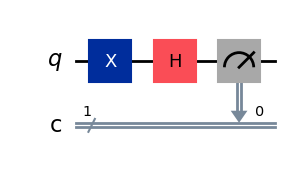

In [43]:
qc = QuantumCircuit(1,1)
qc.x(0)
qc.h(0)
qc.measure(0,0)
qc.draw('mpl')

In [44]:
sim_basic = BasicSimulator()
sim_aer = AerSimulator()

In [45]:
counts_basic = sim_basic.run(qc,shots=100).result().get_counts()
counts_aer = sim_aer.run(qc,shots=100).result().get_counts()

In [46]:
print(counts_basic)
print(counts_aer)

{'1': 53, '0': 47}
{'0': 49, '1': 51}


In [47]:
samp_aer = SamplerV2(mode=sim_aer)

In [52]:
result_aer = samp_aer.run([qc], shots = 100).result()

In [55]:
counts_samp = result_aer[0].data.c.get_counts()
counts_samp

{'1': 46, '0': 54}

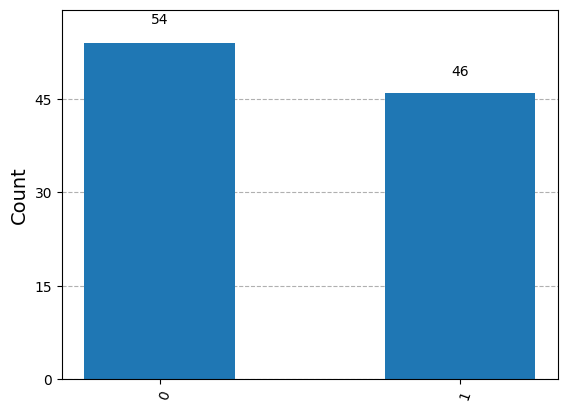

In [56]:
from qiskit.visualization import plot_histogram

plot_histogram(counts_samp)